---
# PART A: Visualization of Activation Functions

We implement Sigmoid, Tanh, and ReLU from scratch (mathematical formulas) and plot:
- The activation function curve
- Its gradient (derivative) curve

Then we compare their properties: output range, saturation regions, gradient behavior,
computational efficiency, and typical applications.


## Import required libraries

In [3]:

import numpy as np
import matplotlib.pyplot as plt
print("NAME: Adhiraj S")
print("ROLL: 24BAD003")

NAME: Adhiraj S
ROLL: 24BAD003


## Define the Activation Functions

In [95]:
# Sigmoid Activation Function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Tanh Activation Function
def tanh(x):
    return np.tanh(x)

# ReLU Activation Function
def relu(x):
    return np.maximum(0, x)

## Generate Input Values

In [96]:
# Generate values from -10 to +10
x = np.linspace(-10, 10, 500)

# Compute outputs
y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_relu = relu(x)


## Plot the Activation Functions

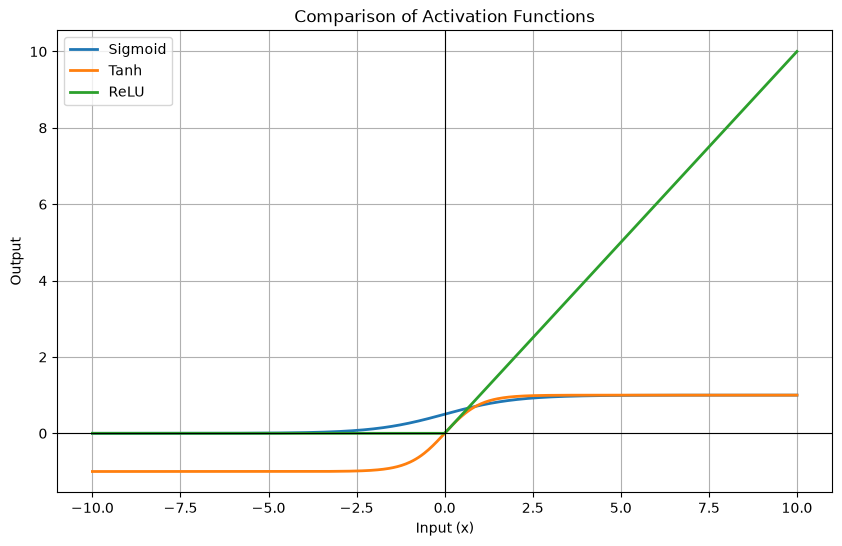

In [97]:
plt.figure(figsize=(10,6))

plt.plot(x, y_sigmoid,
         label='Sigmoid',
         linewidth=2)

plt.plot(x, y_tanh,
         label='Tanh',
         linewidth=2)

plt.plot(x, y_relu,
         label='ReLU',
         linewidth=2)

# Draw X and Y axes
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

# Graph title
plt.title("Comparison of Activation Functions")

# Axis labels
plt.xlabel("Input (x)")
plt.ylabel("Output")

# Grid
plt.grid(True)

# Legend
plt.legend()

# Display graph
plt.show()

## Print Comparison Table

In [98]:
print("\nComparison of Activation Functions\n")

print("{:<12} {:<18} {:<25} {:<22} {:<20}".format(
    "Function",
    "Output Range",
    "Saturation Region",
    "Gradient Behaviour",
    "Typical Applications"
))

print("-"*110)

print("{:<12} {:<18} {:<25} {:<22} {:<20}".format(
    "Sigmoid",
    "(0,1)",
    "Both positive & negative",
    "Vanishing gradient",
    "Binary classification output"
))

print("{:<12} {:<18} {:<25} {:<22} {:<20}".format(
    "Tanh",
    "(-1,1)",
    "Large |x| values",
    "Less vanishing than Sigmoid",
    "Hidden layers"
))

print("{:<12} {:<18} {:<25} {:<22} {:<20}".format(
    "ReLU",
    "[0,∞)",
    "Negative inputs",
    "Fast & sparse activation",
    "Deep neural networks"
))


Comparison of Activation Functions

Function     Output Range       Saturation Region         Gradient Behaviour     Typical Applications
--------------------------------------------------------------------------------------------------------------
Sigmoid      (0,1)              Both positive & negative  Vanishing gradient     Binary classification output
Tanh         (-1,1)             Large |x| values          Less vanishing than Sigmoid Hidden layers       
ReLU         [0,∞)              Negative inputs           Fast & sparse activation Deep neural networks


# Import Required Libraries

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
print("NAME: Adhiraj S")
print("ROLL: 24BAD003")

NAME: Adhiraj S
ROLL: 24BAD003


# Load Fashion MNIST Dataset

In [100]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)


Training Images : (60000, 28, 28)
Training Labels : (60000,)


In [101]:

print("Testing Images  :", x_test.shape)
print("Testing Labels  :", y_test.shape)

Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)


In [102]:


# Normalize pixel values (0-255 → 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Convert labels to One-Hot Encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Function to Create ANN Model

In [103]:
def build_model(activation):

    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation=activation),
        Dense(64, activation=activation),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


---
# PART B: Performance Comparison of Activation Functions

We train **identical ANN architectures** on Fashion MNIST — only the activation function
used in the hidden layers is changed (Sigmoid, Tanh, ReLU) — and compare:
- Training / Validation Accuracy
- Training / Validation Loss
- Epochs required for convergence


## Train Models

In [104]:
activations = ['sigmoid', 'tanh', 'relu']

history_dict = {}
results = []



for activation in activations:

    print(f"\nTraining model using {activation.upper()} activation...\n")

    model = build_model(activation)

    history = model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=15,
        batch_size=128,
        verbose=1
    )

    history_dict[activation] = history

# Store final metrics
    results.append({
        "Activation": activation.upper(),
        "Training Accuracy": history.history['accuracy'][-1],
        "Validation Accuracy": history.history['val_accuracy'][-1],
        "Training Loss": history.history['loss'][-1],
        "Validation Loss": history.history['val_loss'][-1],
        "Epochs": 15
    })

# ----------------------------
# Display Comparison Table
# ----------------------------
results_df = pd.DataFrame(results)

print("\nPerformance Comparison")
print(results_df)


Training model using SIGMOID activation...

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7196 - loss: 0.9244 - val_accuracy: 0.8170 - val_loss: 0.5403
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8345 - loss: 0.4756 - val_accuracy: 0.8381 - val_loss: 0.4465
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8556 - loss: 0.4088 - val_accuracy: 0.8547 - val_loss: 0.3992
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8664 - loss: 0.3762 - val_accuracy: 0.8630 - val_loss: 0.3813
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8731 - loss: 0.3548 - val_accuracy: 0.8668 - val_loss: 0.3659
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8782 - loss: 0.3396 - val_accuracy: 0.8742 - val_loss: 0.3514
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8811 - loss: 0.3256 - val_accuracy: 0.8772 - val_loss: 0.3382
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accur

## Visualization

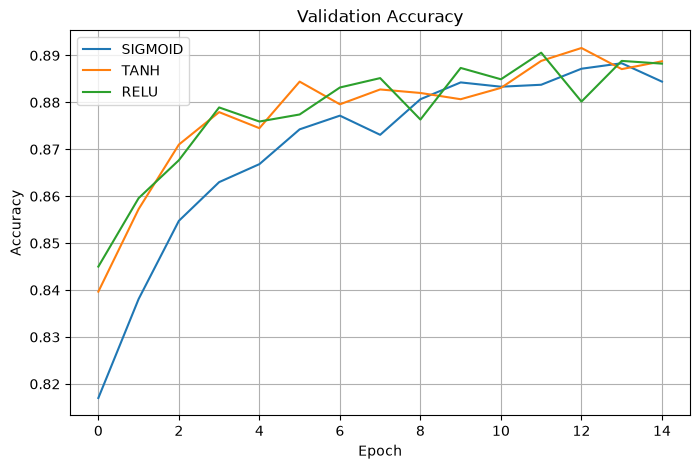

In [105]:
# ----------------------------
# Plot Validation Accuracy
# ----------------------------
plt.figure(figsize=(8,5))

for activation in activations:
    plt.plot(
        history_dict[activation].history['val_accuracy'],
        label=activation.upper()
    )

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

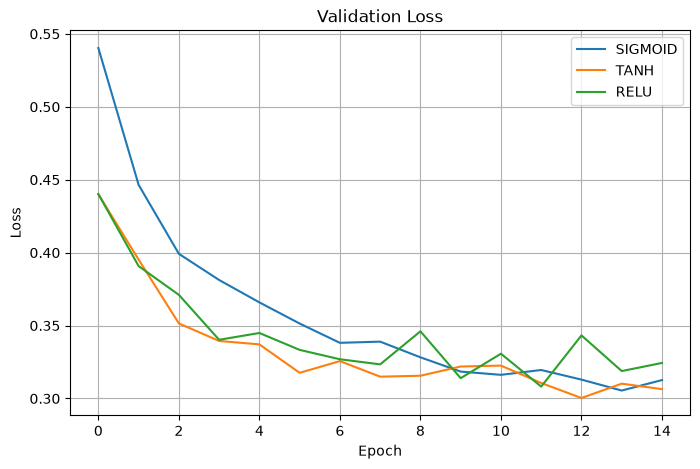

In [106]:
# ----------------------------
# Plot Validation Loss
# ----------------------------
plt.figure(figsize=(8,5))

for activation in activations:
    plt.plot(
        history_dict[activation].history['val_loss'],
        label=activation.upper()
    )

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


## Evaluate on Test Dataset



In [ ]:
print("\nTest Accuracy")

for activation in activations:

    model = build_model(activation)

    model.fit(
        x_train,
        y_train,
        epochs=15,
        batch_size=128,
        verbose=0
    )

    test_loss, test_accuracy = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    print(f"{activation.upper():8s} : {test_accuracy:.4f}")


Test Accuracy


C:\Users\Adhi\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


SIGMOID  : 0.8798


**Analysis (fill in based on your actual run results):**
Typically, **ReLU** converges fastest and achieves the highest training/validation accuracy
because it avoids vanishing gradients. **Sigmoid** usually converges slowest and may show
signs of vanishing gradient (accuracy plateaus early). **Tanh** performs better than Sigmoid
(zero-centered output) but still slower than ReLU.


---
## PART C: Comparison of Optimization Algorithms

Using the **same ANN architecture** (with ReLU activation, since it performed best in Part B),
we train the model with different optimizers:
- SGD (Stochastic Gradient Descent)
- Momentum (SGD with momentum)
- RMSProp
- Adam

and compare training/validation loss & accuracy and convergence speed.


In [2]:
print("NAME: Adhiraj S")
print("ROLL: 24BAD003")

NAME: Adhiraj S
ROLL: 24BAD003


In [ ]:
# ============================================================
# Function to Build ANN Model
# ============================================================

def build_model(optimizer):

    model = Sequential([

        Flatten(input_shape=(28,28)),

        Dense(128, activation='relu'),

        Dense(64, activation='relu'),

        Dense(10, activation='softmax')

    ])

    model.compile(

        optimizer=optimizer,

        loss='categorical_crossentropy',

        metrics=['accuracy']

    )

    return model

## Optimizers to Compare

In [ ]:

optimizers = {

    "SGD": SGD(),

    "Momentum": SGD(momentum=0.9),

    "RMSProp": RMSprop(),

    "Adam": Adam()

}

## Train the ANN Using Different Optimizers

In [ ]:
# ============================================================
# Train the ANN Using Different Optimizers
# ============================================================

history_data = {}

results = []

for optimizer_name, optimizer in optimizers.items():

    print("\nTraining Model using", optimizer_name)

    model = build_model(optimizer)

    history = model.fit(

        x_train,

        y_train,

        validation_split=0.20,

        epochs=15,

        batch_size=128,

        verbose=1

    )

    history_data[optimizer_name] = history

    results.append({

        "Optimizer": optimizer_name,

        "Training Accuracy": history.history['accuracy'][-1],

        "Validation Accuracy": history.history['val_accuracy'][-1],

        "Training Loss": history.history['loss'][-1],

        "Validation Loss": history.history['val_loss'][-1],

        "Epochs": len(history.history['loss'])

    })


Training Model using SGD
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6254 - loss: 1.2379 - val_accuracy: 0.7284 - val_loss: 0.8049
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7581 - loss: 0.7188 - val_accuracy: 0.7821 - val_loss: 0.6401
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7977 - loss: 0.6066 - val_accuracy: 0.8111 - val_loss: 0.5667
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8150 - loss: 0.5524 - val_accuracy: 0.8154 - val_loss: 0.5317
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8245 - loss: 0.5194 - val_accuracy: 0.8219 - val_loss: 0.5113
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8311 - loss: 0.4968 - val_accuracy: 0.8307 - val_loss: 0.4895
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8342 - loss: 0.4811 - val_accuracy: 0.8328 - val_loss: 0.4888
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8391 - loss:

## Visualization

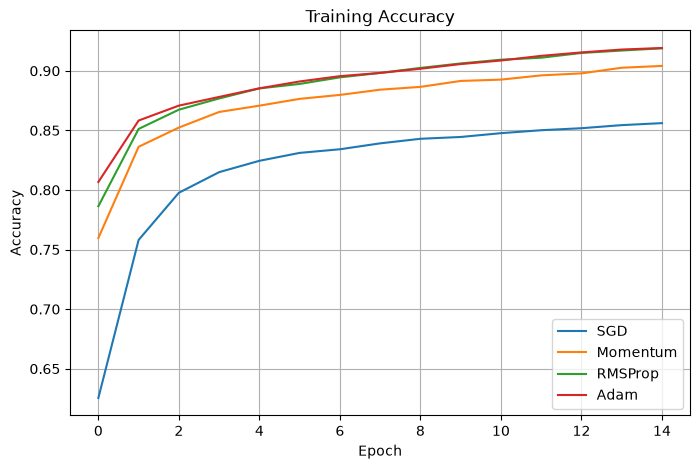

In [ ]:
# ============================================================
# Training Accuracy Comparison
# ============================================================

plt.figure(figsize=(8,5))

for optimizer in optimizers.keys():

    plt.plot(
        history_data[optimizer].history['accuracy'],
        label=optimizer
    )

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()



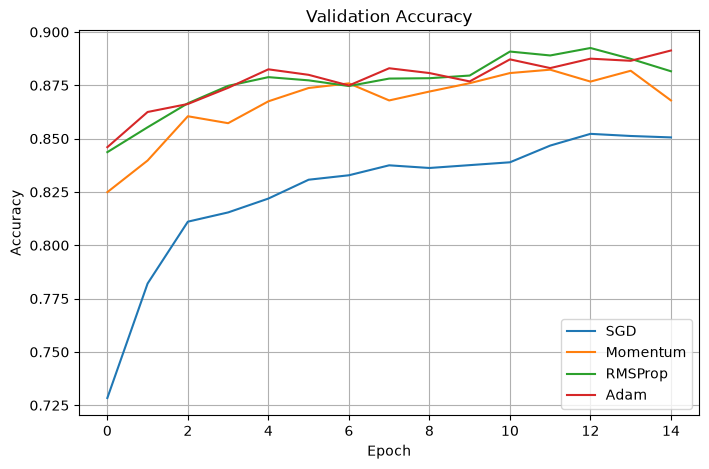

In [ ]:
# ============================================================
# Validation Accuracy Comparison
# ============================================================

plt.figure(figsize=(8,5))

for optimizer in optimizers.keys():

    plt.plot(

        history_data[optimizer].history['val_accuracy'],
        label=optimizer

    )

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

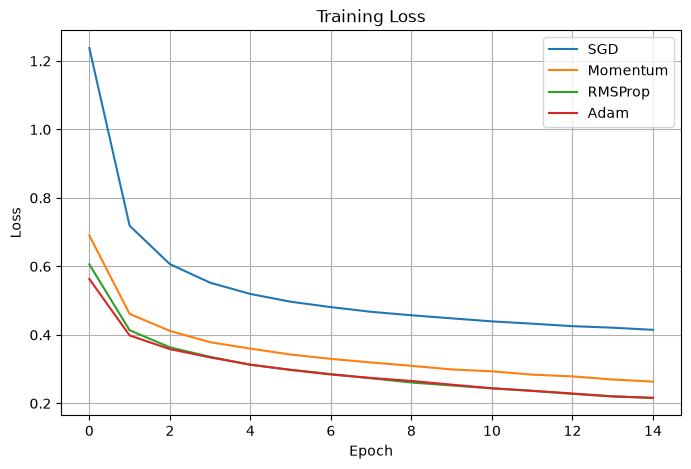

In [ ]:
# ============================================================
# Training Loss Comparison
# ============================================================

plt.figure(figsize=(8,5))

for optimizer in optimizers.keys():

    plt.plot(

        history_data[optimizer].history['loss'],

        label=optimizer

    )

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

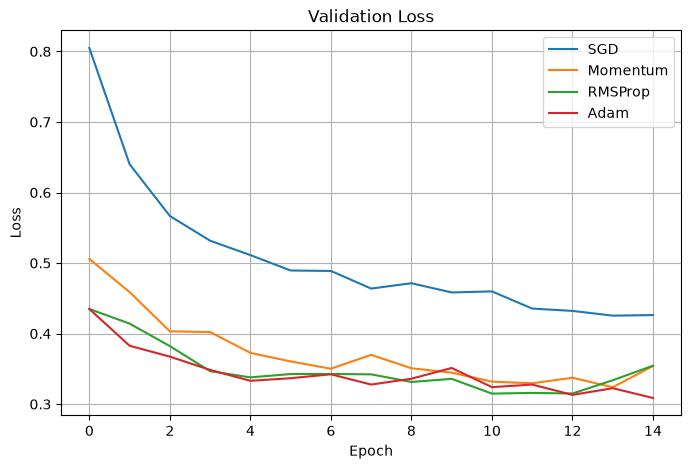

In [ ]:
# ============================================================
# Validation Loss Comparison
# ============================================================

plt.figure(figsize=(8,5))

for optimizer in optimizers.keys():

    plt.plot(

        history_data[optimizer].history['val_loss'],

        label=optimizer

    )

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# Best Optimizer Based on Validation Accuracy
# ============================================================

best_optimizer = results_df.loc[
    results_df['Validation Accuracy'].idxmax()
]

print("\nBest Optimizer\n")

print(best_optimizer)


Best Optimizer

Activation                 RELU
Training Accuracy      0.918813
Validation Accuracy    0.892417
Training Loss          0.216545
Validation Loss        0.321462
Epochs                       15
Name: 2, dtype: object


**Analysis (fill in based on your actual run results):**
**Adam** typically converges fastest and gives the best overall balance of training speed and
generalization, since it combines momentum with adaptive learning rates. **RMSProp** also
converges quickly. **Momentum**-based SGD converges faster than plain **SGD**, which is usually
the slowest to converge and may require more epochs / a higher learning rate to reach comparable
accuracy.


---
## Conclusion

- **Part A** showed that ReLU avoids the saturation problem seen in Sigmoid and Tanh, and is
  computationally cheaper (no exponential calculation).
- **Part B** showed that on Fashion MNIST, ReLU achieves the best training/validation accuracy
  and lowest loss compared to Sigmoid and Tanh, for the same architecture and epochs.
- **Part C** showed that adaptive optimizers (Adam, RMSProp) converge faster and generalize
  better than plain SGD, with Momentum improving over vanilla SGD.
